[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/charlieh0tel/ee_stuff/blob/main/calculators/thermistors/ThermistorBuffering.ipynb)

# Inspired by TI App Note SBOA323A

https://www.ti.com/lit/an/sboa323a/sboa323a.pdf


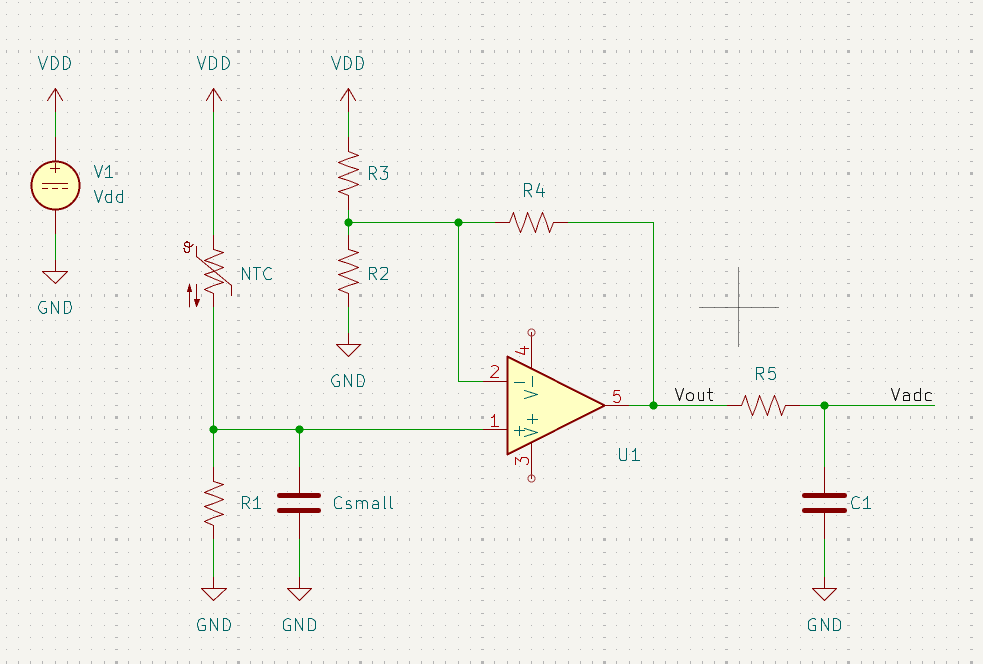

In [ ]:
# @title Code

%pip install quantities
%pip install eseries

import dataclasses
import string

import numpy as np
import quantities as pq
import eseries

import matplotlib.pyplot as plt
from IPython.display import HTML


@dataclasses.dataclass
class Thermistor:
  r0: pq.Quantity
  t0: pq.Quantity
  B: pq.Quantity

  def _r_inf(self):
    return self.r0 * np.exp(-self.B / self.t0)

  def r(self, t):
    return self._r_inf() * np.exp(self.B / t)

  def t(self, r):
    return self.B / np.log(r / self._r_inf())

  def __str__(self):
    return f"Thermistor(r0={self.r0}, t0={self.t0}, B={self.B})"


def CtoK(t): return (273.15 + t) * pq.degK

def KtoC(t): return (t.magnitude - 273.15) * pq.degC


def Rpar(*resistors):
    r_list = np.array(resistors).flatten()
    if len(r_list) == 0:
        return 0.0 * pq.Ohm
    magnitudes = [pq.Quantity(res, pq.Ohm).rescale(pq.Ohm).magnitude for res in r_list]
    inv_sum = np.sum(1.0 / np.array(magnitudes))
    result_magnitude = 1.0 / inv_sum
    return pq.Quantity(result_magnitude, pq.Ohm)


def p(s):
  identifiers = [name for _, name, _, _ in string.Formatter().parse(s) if name is not None]
  print(f"{', '.join(identifiers)} = ", end="")
  eval('print(' + 'f"%s"' % s + ')')


def eseries_wrapper(function, series, value):
  return function(series, value.magnitude) * value.units


@dataclasses.dataclass
class DesignInputs:
    resistor_series: eseries.ESeries
    capacitor_series: eseries.ESeries
    ntc: Thermistor
    Tmin: pq.Quantity
    Tmax: pq.Quantity
    Vdd: pq.Quantity
    Vout_min: pq.Quantity
    Vout_max: pq.Quantity
    R4_ideal: pq.Quantity
    R5_ideal: pq.Quantity
    Csmall_ideal: pq.Quantity
    fc_ideal: pq.Quantity

@dataclasses.dataclass
class DesignResults:
    R1: pq.Quantity
    R2: pq.Quantity
    R3: pq.Quantity
    R4: pq.Quantity
    R5: pq.Quantity
    C1: pq.Quantity
    Csmall: pq.Quantity
    gain_actual: pq.Quantity
    fcsmall_actual: pq.Quantity
    fc1_actual: pq.Quantity


def calculate_design(inputs: DesignInputs) -> DesignResults:
    # 1. Thermistor resistance at extremes
    Rntc_tmax = inputs.ntc.r(inputs.Tmax)
    Rntc_tmin = inputs.ntc.r(inputs.Tmin)

    # 2. Select R1 (geometric mean for best linearity)
    R1_ideal = np.sqrt(Rntc_tmax * Rntc_tmin)
    R1 = eseries_wrapper(eseries.find_greater_than_or_equal, inputs.resistor_series, R1_ideal)

    # 3. Calculate input voltage range
    Vin_max = inputs.Vdd * (R1 / (Rntc_tmax + R1))
    Vin_min = inputs.Vdd * (R1 / (Rntc_tmin + R1))

    # 4. Determine required ideal gain
    G_ideal = ((inputs.Vout_max - inputs.Vout_min) / (Vin_max - Vin_min)) * pq.CompoundUnit("V/V")

    # 5. Fix R4 and calculate R2/R3 network
    R4 = eseries.find_nearest(inputs.resistor_series, inputs.R4_ideal.magnitude) * pq.Ohm
    R2_par_R3_ideal = (R4 / (G_ideal - 1.)).rescale(pq.Ohm)
    R3_ideal = (R4 * inputs.Vdd / (Vin_max * G_ideal - inputs.Vout_max)).rescale(pq.Ohm)
    R2_ideal = R2_par_R3_ideal * R3_ideal / (R3_ideal - R2_par_R3_ideal)

    R3 = eseries_wrapper(eseries.find_nearest, inputs.resistor_series, R3_ideal)
    R2 = eseries_wrapper(eseries.find_nearest, inputs.resistor_series, R2_ideal)
    R5 = eseries.find_nearest(inputs.resistor_series, inputs.R5_ideal.magnitude) * pq.Ohm

    # 6. Actual Gain and Capacitors
    gain_actual = ((Rpar(R2, R3) + R4) / Rpar(R2, R3)) * pq.CompoundUnit("V/V")
    Csmall = eseries_wrapper(eseries.find_nearest, inputs.capacitor_series, inputs.Csmall_ideal)
    C1_ideal = (1 / (2 * np.pi * R5 * inputs.fc_ideal)).rescale(pq.uF)
    C1 = eseries_wrapper(eseries.find_nearest, inputs.capacitor_series, C1_ideal)

    # 7. Final frequency analysis
    fcsmall_actual = (1. / (2. * np.pi * Rpar(inputs.ntc.r0, R1) * Csmall)).rescale(pq.Hz)
    fc1_actual = (1. / (2. * np.pi * R5 * C1)).rescale(pq.Hz)

    return DesignResults(
        R1=R1, R2=R2, R3=R3, R4=R4, R5=R5, C1=C1, Csmall=Csmall,
        gain_actual=gain_actual, fcsmall_actual=fcsmall_actual, fc1_actual=fc1_actual
    )


def plot_frequency_response(results, inputs, f_start=1*pq.Hz, f_stop=1e6*pq.Hz, use_log=True):
    # Ensure f_start and f_stop are positive when use_log is True to avoid log10(0) warnings.
    if use_log:
      f = np.logspace(np.log10(f_start.magnitude), np.log10(f_stop.magnitude), 500) * pq.Hz
    else:
      f = np.linspace(f_start.magnitude, f_stop.magnitude, 1000) * pq.Hz

    w = 2 * np.pi * f

    # Input Filter (RC with Rpar of NTC and R1)
    R_src = Rpar(inputs.ntc.r0, results.R1)
    H1 = 1 / (1 + 1j * w * R_src * results.Csmall)

    # Output Filter (R5 and C1)
    H2 = 1 / (1 + 1j * w * results.R5 * results.C1)

    # Combined Response
    H_total = H1 * H2
    mag_linear = np.abs(H_total).rescale(pq.dimensionless).magnitude
    mag_db = 20 * np.log10(mag_linear)
    phase_deg = np.angle(H_total, deg=True)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # Magnitude Plot
    if use_log:
      ax1.semilogx(f.magnitude, mag_db)
    else:
      ax1.plot(f.magnitude, mag_db)

    ax1.axvline(results.fcsmall_actual.magnitude, color='r', linestyle='--', label=f'Input Cutoff ({results.fcsmall_actual:.1f})')
    ax1.axvline(results.fc1_actual.magnitude, color='g', linestyle='--', label=f'Output Cutoff ({results.fc1_actual:.1f})')
    ax1.set_title("Filter Frequency Response")
    ax1.set_ylabel("Gain (dB)")
    ax1.grid(True, which="both", ls="-", alpha=0.5)
    ax1.legend()
    ax1.set_ylim(-60, 5)

    # Phase Plot
    if use_log:
      ax2.semilogx(f.magnitude, phase_deg, color='orange')
    else:
      ax2.plot(f.magnitude, phase_deg, color='orange')

    ax2.set_ylabel("Phase (deg)")
    ax2.set_xlabel("Frequency (Hz)")
    ax2.set_yticks([-180, -135, -90, -45, 0])
    ax2.grid(True, which="both", ls="-", alpha=0.5)

    plt.tight_layout()
    plt.show()


def display_results_table(inputs, results):
    def fmt_c(q):
        return f"{KtoC(q).magnitude:.1f} °C"

    html = f'''
    <div style="font-family: Arial, sans-serif; max-width: 600px; border: 1px solid #ddd; border-radius: 8px; padding: 20px; background-color: #f9f9f9;">
        <h2 style="color: #2c3e50; margin-top: 0;">Refined Circuit Design Summary</h2>

        <h3 style="color: #2c3e50; border-bottom: 1px solid #bdc3c7; padding-bottom: 5px;">Input Parameters</h3>
        <table style="width: 100%; border-collapse: collapse; margin-bottom: 15px;">
            <tr><td style="padding: 4px 0;"><b>NTC:</b> R₀={inputs.ntc.r0}, T₀={fmt_c(inputs.ntc.t0)}, B={inputs.ntc.B}</td></tr>
            <tr><td style="padding: 4px 0;"><b>Range:</b> {fmt_c(inputs.Tmin)} to {fmt_c(inputs.Tmax)}</td></tr>
            <tr><td style="padding: 4px 0;"><b>Rails:</b> Vdd={inputs.Vdd}, Vout={inputs.Vout_min} to {inputs.Vout_max}</td></tr>
            <tr><td style="padding: 4px 0;"><b>Series:</b> {inputs.resistor_series.name} (R) / {inputs.capacitor_series.name} (C)</td></tr>
        </table>

        <h3 style="color: #2c3e50; border-bottom: 1px solid #bdc3c7; padding-bottom: 5px;">Selected Components</h3>
        <table style="width: 100%; border-collapse: collapse; margin-bottom: 15px;">
            <tr style="background-color: #ecf0f1;">
                <th style="text-align: left; padding: 8px; border-bottom: 2px solid #bdc3c7;">Component</th>
                <th style="text-align: right; padding: 8px; border-bottom: 2px solid #bdc3c7;">Value</th>
            </tr>
            <tr><td style="padding: 8px; border-bottom: 1px solid #eee;"><b>R1</b> (Bias)</td><td style="text-align: right; padding: 8px; border-bottom: 1px solid #eee;">{results.R1}</td></tr>
            <tr><td style="padding: 8px; border-bottom: 1px solid #eee;"><b>R2</b> (Gain Set)</td><td style="text-align: right; padding: 8px; border-bottom: 1px solid #eee;">{results.R2}</td></tr>
            <tr><td style="padding: 8px; border-bottom: 1px solid #eee;"><b>R3</b> (Offset)</td><td style="text-align: right; padding: 8px; border-bottom: 1px solid #eee;">{results.R3}</td></tr>
            <tr><td style="padding: 8px; border-bottom: 1px solid #eee;"><b>R4</b> (Feedback)</td><td style="text-align: right; padding: 8px; border-bottom: 1px solid #eee;">{results.R4}</td></tr>
            <tr><td style="padding: 8px; border-bottom: 1px solid #eee;"><b>R5</b> (Filter)</td><td style="text-align: right; padding: 8px; border-bottom: 1px solid #eee;">{results.R5}</td></tr>
            <tr><td style="padding: 8px; border-bottom: 1px solid #eee;"><b>Csmall</b> (LPF 1)</td><td style="text-align: right; padding: 8px; border-bottom: 1px solid #eee;">{results.Csmall}</td></tr>
            <tr><td style="padding: 8px; border-bottom: 1px solid #eee;"><b>C1</b> (LPF 2)</td><td style="text-align: right; padding: 8px; border-bottom: 1px solid #eee;">{results.C1}</td></tr>
        </table>

        <h3 style="color: #2c3e50; border-bottom: 1px solid #bdc3c7; padding-bottom: 5px;">Performance Verification</h3>
        <ul style="list-style-type: none; padding-left: 0;">
            <li style="padding: 4px 0;"><b>Actual Gain:</b> {results.gain_actual:.3f}</li>
            <li style="padding: 4px 0;"><b>Input Cutoff:</b> {results.fcsmall_actual:.2f}</li>
            <li style="padding: 4px 0;"><b>Output Cutoff:</b> {results.fc1_actual:.2f}</li>
        </ul>
    '''
    if results.R3 > 10e3 * pq.ohm or results.R2 > 10e3 * pq.ohm:
      html += '<p style="color: #e74c3c; font-weight: bold; margin-top: 10px;">Recommendation: decrease R4 to bring R2 and R3 under 10K Ohm</p>'

    if results.C1 > 47 * pq.uF:
      html += '<p style="color: #e74c3c; font-weight: bold; margin-top: 10px;">Warning: C1 may be too large (bigger than typical 1210 X7R 16V).</p>'

    html += '</div>'
    display(HTML(html))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.0/104.0 kB 7.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=a6a953d7a778af6b1b03a81609736189e631edcaf321fe83d79add94671880d4
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built docopt


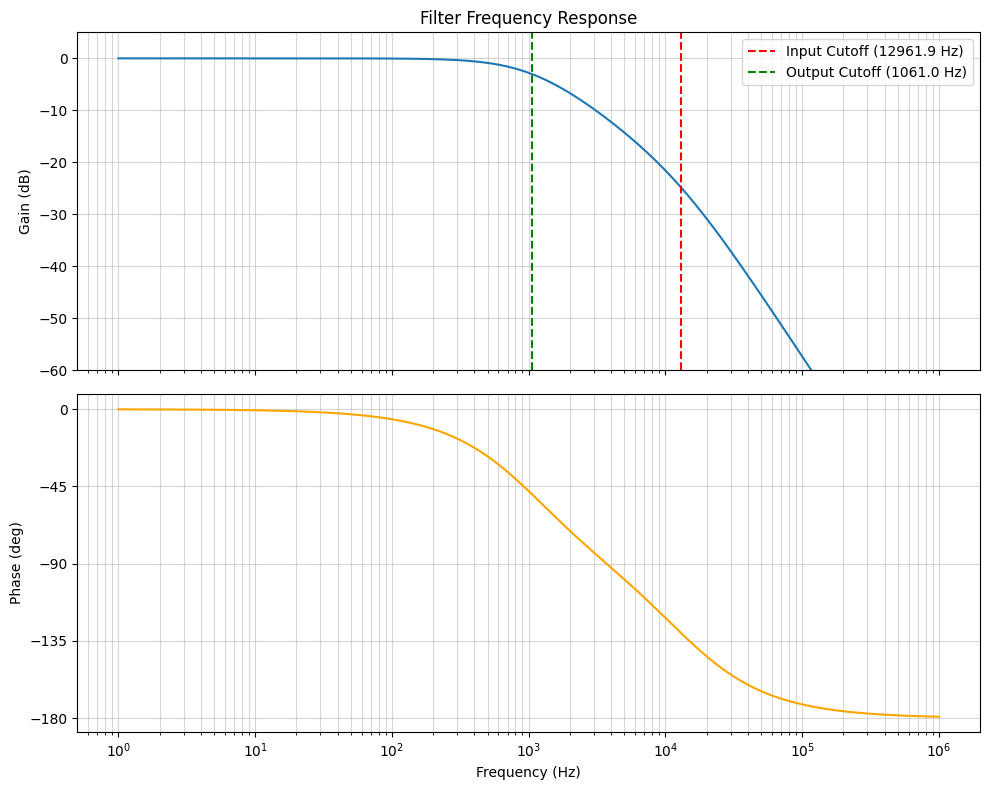

In [ ]:
# @title Design Parameters { run: "auto" }

_ESERIES_MAP = {
    "E6": eseries.E6,
    "E12": eseries.E12,
    "E24": eseries.E24,
    "E48": eseries.E48,
    "E96": eseries.E96,
    "E192": eseries.E192
}

# @markdown ### E-Series Selections
resistors = "E12" # @param ["E6", "E12", "E24", "E48", "E96", "E192"] {type:"string"}

resistor_eseries = _ESERIES_MAP.get(resistors, eseries.E24)

capacitors = "E12" # @param ["E6", "E12", "E24", "E48", "E96", "E192"] {type:"string"}
capacitor_eseries = _ESERIES_MAP.get(capacitors, eseries.E12)

# @markdown ### Thermistor Parameters
r0_Ω = 2252.0 # @param {type:"number"}
t0_C = 25.0 # @param {type:"number"}
B_K = 3900.0 # @param {type:"number"}
ntc_thermistor = Thermistor(r0_Ω * pq.Ohm, CtoK(t0_C), B_K * pq.degK)

# @markdown ### Temperature Range
Tmin_C = 0.0 # @param {type:"number"}
Tmin = CtoK(Tmin_C)
Tmax_C = 50 # @param {type:"number"}
Tmax = CtoK(Tmax_C)

# @markdown ### Voltage Rails & Output Margins
Vdd_V = 3.3 # @param {type:"number"}
Vdd = Vdd_V * pq.V
Vout_margin_percent = 5.0 # @param {type:"number", min_value:0, max_value:100}
Vout_max = Vdd * (1 - Vout_margin_percent / 100.0)
Vout_min = Vdd * (Vout_margin_percent / 100.0)

# @markdown ### Fixed Resistor Defaults (Don't Touch or Adjust After Consideration)
# @markdown #### <font size=-8>R4 should be reduced only if R2 or R3 are greater than 10K Ω</font>
R4_ideal_Ω = 1500 # @param {type:"number"}
R4_ideal = R4_ideal_Ω * pq.Ohm

# @markdown #### <font size=-8>R5 should be small, 50-330 Ω to avoid loading the Csamp at the ADC.</font>
R5_ideal_Ω = 100 # @param {type:"number"}
R5_ideal = R5_ideal_Ω * pq.Ohm

# @markdown ### Filter Capacitor & Cutoff
Csmall_ideal_nF = 100 # @param {type:"number"}
Csmall_ideal = Csmall_ideal_nF * pq.nF
fc_ideal_Hz = 1000 # @param {type:"number"}
fc_ideal = fc_ideal_Hz * pq.Hz

# @markdown ### Visualization
log_frequency_scale = True # @param {type:"boolean"}

inputs = DesignInputs(
    resistor_series=resistor_eseries,
    capacitor_series=capacitor_eseries,
    ntc=ntc_thermistor,
    Tmin=Tmin,
    Tmax=Tmax,
    Vdd=Vdd,
    Vout_min=Vout_min,
    Vout_max=Vout_max,
    R4_ideal=R4_ideal,
    R5_ideal=R5_ideal,
    Csmall_ideal=Csmall_ideal,
    fc_ideal=fc_ideal
)

results = calculate_design(inputs)

display_results_table(inputs, results)
plot_frequency_response(results, inputs, use_log=log_frequency_scale)
